In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

In [22]:
# Generate 2000 hourly timestamps
start_time = datetime(2024, 1, 1, 0, 0, 0)
timestamps = [start_time + timedelta(hours=i) for i in range(2000)]

vehicle_counts = []

for i in range(2000):
    hour = timestamps[i].hour
    day = timestamps[i].weekday()
    
    # Base traffic (low range)
    base = 5
    
    # Morning peak (8-10 AM)
    morning_peak = 6 * np.exp(-0.5 * (hour - 9)**2 / 2)
    
    # Evening peak (5-8 PM)
    evening_peak = 8 * np.exp(-0.5 * (hour - 18)**2 / 3)
    
    # Night low traffic
    night_drop = -2 if hour < 5 else 0
    
    # Weekend effect
    weekend_effect = -3 if day >= 5 else 0
    
    # Very slight increasing trend
    trend = 0.002 * i
    
    # Small noise
    noise = np.random.normal(0, 1)
    
    traffic = base + morning_peak + evening_peak + night_drop + weekend_effect + trend + noise
    
    # Keep strictly between 1 and 20
    traffic = np.clip(traffic, 1, 20)
    
    vehicle_counts.append(int(round(traffic)))

# Create DataFrame
df = pd.DataFrame({
    "time": timestamps,
    "number_of_vehicles": vehicle_counts
})

df.head()

,time,number_of_vehicles
0,2024-01-01 00:00:00,3
1,2024-01-01 01:00:00,2
2,2024-01-01 02:00:00,3
3,2024-01-01 03:00:00,4
4,2024-01-01 04:00:00,3


In [23]:
df.to_csv("traffic_dataset.csv", index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


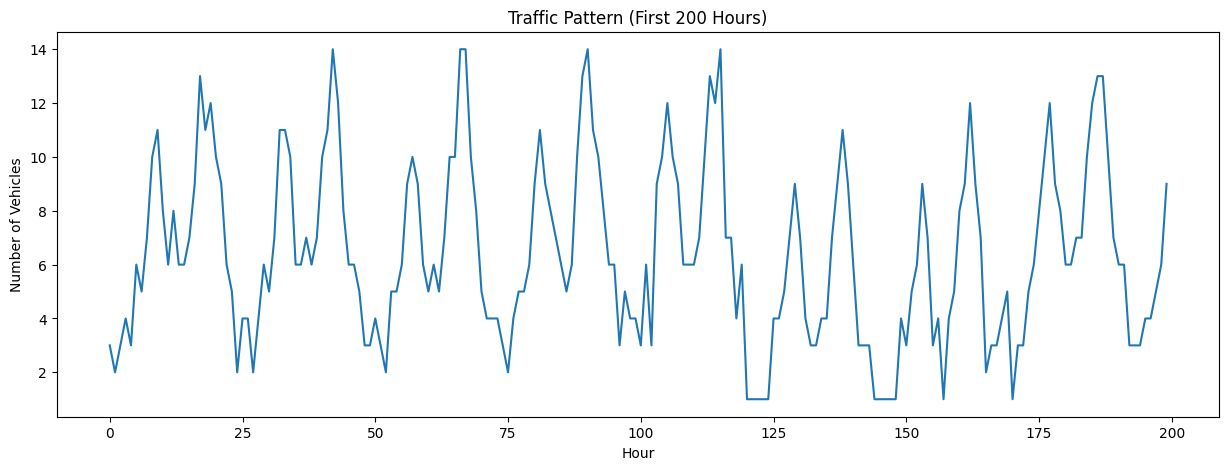

In [24]:
plt.figure(figsize=(15,5))
plt.plot(df["number_of_vehicles"][:200])
plt.title("Traffic Pattern (First 200 Hours)")
plt.xlabel("Hour")
plt.ylabel("Number of Vehicles")
plt.show()

In [25]:
df = pd.read_csv("traffic_dataset.csv")
df.head()

,time,number_of_vehicles
0,2024-01-01 00:00:00,3
1,2024-01-01 01:00:00,2
2,2024-01-01 02:00:00,3
3,2024-01-01 03:00:00,4
4,2024-01-01 04:00:00,3


In [26]:
data = df.drop("time", axis=1)
data.head()

,number_of_vehicles
0,3
1,2
2,3
3,4
4,3


In [27]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [28]:
def create_sequences(data, seq_length=10):
    X = []
    y = []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 10)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1990, 10, 1)
y shape: (1990, 1)


In [29]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (1592, 10, 1)
Testing Samples: (398, 10, 1)


In [30]:
model = Sequential()

model.add(LSTM(64, activation='relu', input_shape=(10,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 64)                16896     
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 16,961
Trainable params: 16,961
Non-trainable params: 0
_________________________________________________________________


In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/100
50/50 [==============================] - 2s 13ms/step - loss: 0.0736 - val_loss: 0.0400
Epoch 2/100
50/50 [==============================] - 0s 8ms/step - loss: 0.0323 - val_loss: 0.0334
Epoch 3/100
50/50 [==============================] - 1s 12ms/step - loss: 0.0288 - val_loss: 0.0263
Epoch 4/100
50/50 [==============================] - 0s 8ms/step - loss: 0.0237 - val_loss: 0.0212
Epoch 5/100
50/50 [==============================] - 0s 7ms/step - loss: 0.0184 - val_loss: 0.0189
Epoch 6/100
50/50 [==============================] - 0s 8ms/step - loss: 0.0139 - val_loss: 0.0112
Epoch 7/100
50/50 [==============================] - 0s 7ms/step - loss: 0.0109 - val_loss: 0.0121
Epoch 8/100
50/50 [==============================] - 0s 7ms/step - loss: 0.0109 - val_loss: 0.0107
Epoch 9/100
50/50 [==============================] - 0s 7ms/step - loss: 0.0100 - val_loss: 0.0128
Epoch 10/100
50/50 [==============================] - 0s 7ms/step - loss: 0.0101 - val_loss: 0.0109
Epoch 1

In [32]:
model.save("traffic_rnn_model.h5")
print("Model Saved Successfully")

Model Saved Successfully


In [33]:
loaded_model = load_model("traffic_rnn_model.h5")
print("Model Loaded Successfully")

Model Loaded Successfully


In [34]:
last_10_hours = scaled_data[-10:]
last_10_hours = last_10_hours.reshape(1,10,1)

prediction = loaded_model.predict(last_10_hours)

# Convert back to original scale
predicted_vehicles = scaler.inverse_transform(prediction)

print("Predicted Next Hour Vehicles:", int(predicted_vehicles[0][0]))

Predicted Next Hour Vehicles: 9


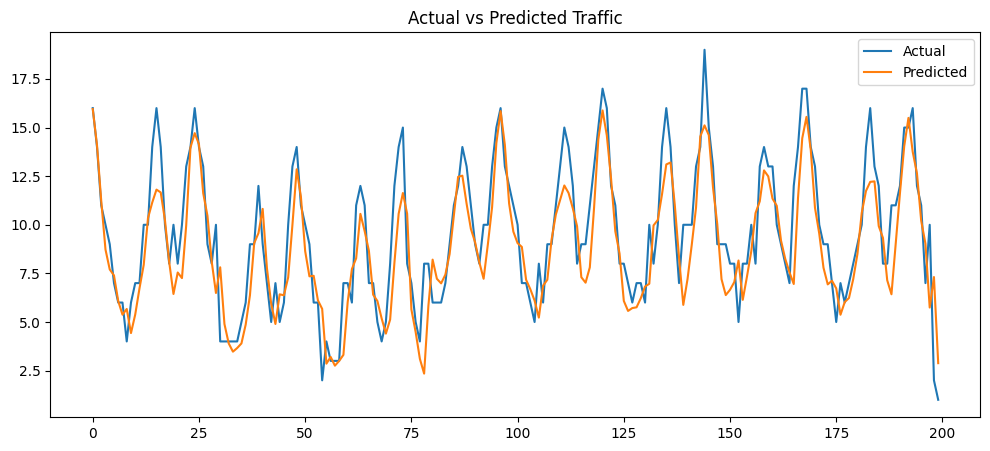

In [35]:
predictions = loaded_model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,5))
plt.plot(y_test_actual[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Traffic")
plt.show()

In [36]:
import joblib

# Save scaler
joblib.dump(scaler, "traffic_scaler.save")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [37]:
# Load scaler
loaded_scaler = joblib.load("traffic_scaler.save")

print("Scaler Loaded Successfully")

Scaler Loaded Successfully


In [38]:
import numpy as np
from tensorflow.keras.models import load_model
import joblib

def predict_next_hour(vehicle_list):
    
    # Check input length
    if len(vehicle_list) != 10:
        raise ValueError("Input list must contain exactly 10 values.")
    
    # Convert to numpy array
    vehicle_array = np.array(vehicle_list).reshape(-1, 1)
    
    # Load scaler
    scaler = joblib.load("traffic_scaler.save")
    
    # Scale input
    scaled_input = scaler.transform(vehicle_array)
    
    # Reshape for LSTM (1 sample, 10 timesteps, 1 feature)
    scaled_input = scaled_input.reshape(1, 10, 1)
    
    # Load model
    model = load_model("traffic_rnn_model.h5")
    
    # Predict
    prediction = model.predict(scaled_input)
    
    # Inverse scale
    predicted_value = scaler.inverse_transform(prediction)
    
    return int(predicted_value[0][0])

In [39]:
predict_next_hour([1,2,3,4,5,6,7,8,9,10])

C:\Users\HP\anaconda3\envs\smartai\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  "X does not have valid feature names, but"


7